<a href="https://colab.research.google.com/github/Jeevith252/ML_BASIC_PROJECT/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix , classification_report

In [10]:
(x_train , y_train) , (x_test , y_test) = tf.keras.datasets.cifar10.load_data()

In [11]:
print(x_train.shape)
print(x_test.shape)
print(y_train[:10])

(50000, 32, 32, 3)
(10000, 32, 32, 3)
[[6]
 [9]
 [9]
 [4]
 [1]
 [1]
 [2]
 [7]
 [8]
 [3]]


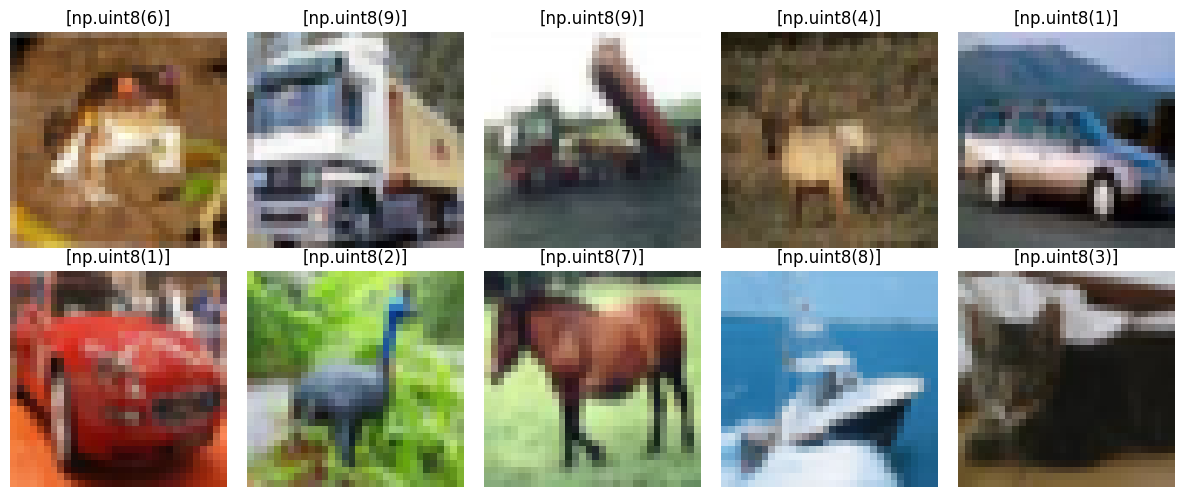

In [12]:
plt.figure(figsize=(12,5))

for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(x_train[i])
  plt.title([y_train[i][0]])
  plt.axis("off")
plt.tight_layout()

In [13]:

class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Forg",
    "Horse",
    "Ship",
    "Truck"
]

In [14]:
print(x_train[0])

[[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]


In [15]:
x_train = x_train / 255.0

x_test = x_test /255.0

print("Maximum : ", x_train.min())
print("Maximum : ",x_train.max())



Maximum :  0.0
Maximum :  1.0


In [16]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(32, 32, 3)),

    tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    tf.keras.layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        units=64,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        units=10,
        activation="softmax"
    )
])

In [21]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [22]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 67s 52ms/step - accuracy: 0.4691 - loss: 1.4905 - val_accuracy: 0.5560 - val_loss: 1.2427
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 52s 42ms/step - accuracy: 0.6028 - loss: 1.1318 - val_accuracy: 0.6193 - val_loss: 1.1009
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 48s 38ms/step - accuracy: 0.6516 - loss: 1.0012 - val_accuracy: 0.6423 - val_loss: 1.0346
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 48s 38ms/step - accuracy: 0.6750 - loss: 0.9261 - val_accuracy: 0.6583 - val_loss: 0.9870
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 38ms/step - accuracy: 0.6985 - loss: 0.8594 - val_accuracy: 0.6334 - val_loss: 1.0701
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 47s 38ms/step - accuracy: 0.7228 - loss: 0.7999 - val_accuracy: 0.6744 - val_loss: 0.9504
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 85s 40ms/step - accuracy: 0.7404 - loss: 0.7442 - val_accuracy: 0.6667 - val_loss: 0.9875
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 47s 38ms/step - accuracy: 0.7541 -

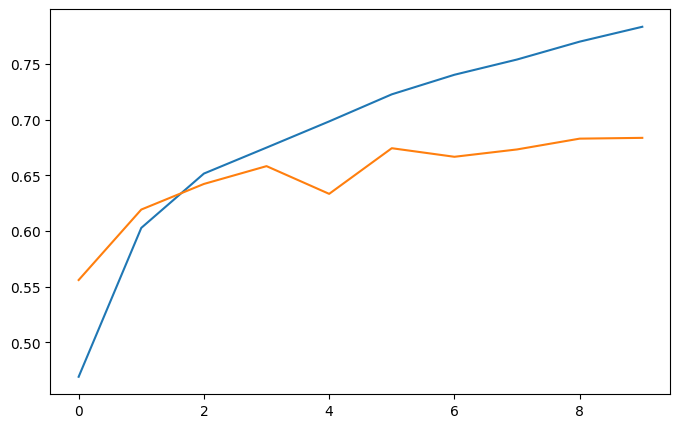

In [23]:
plt.figure(figsize = (8,5))
plt.plot(history.history["accuracy"] , label = "Training Accuracy")
plt.plot(history.history["val_accuracy"] , label = "Validation Acuuracy")
plt.show()

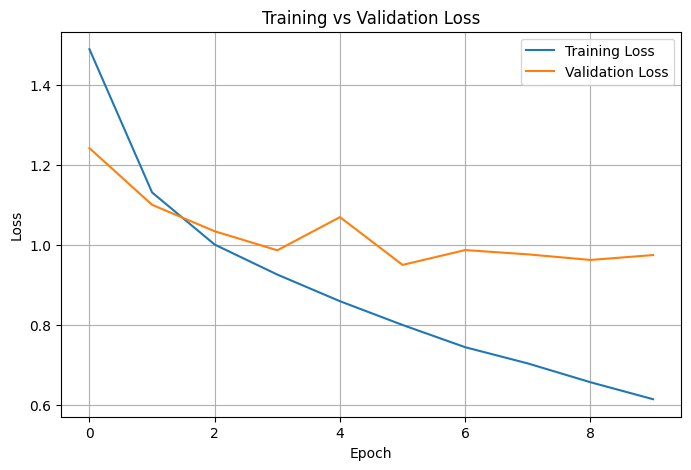

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

In [29]:
predictions = model.predict(x_test)


predicted_label = np.argmax(predictions[0])
print("Predicted Digit : " , predicted_label)
print("Actual Digit : ", y_test[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Predicted Digit :  3
Actual Digit :  [3]


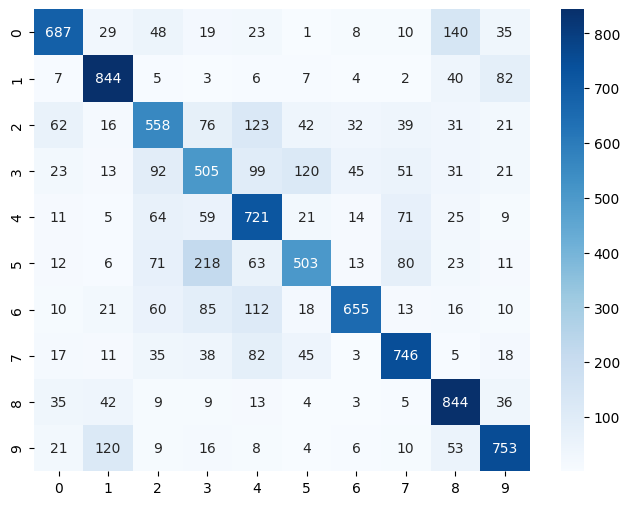

In [33]:
y_pred = np.argmax(predictions ,axis = 1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm , annot =True , fmt = "d",
            cmap = "Blues")
plt.show()

In [34]:
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           0       0.78      0.69      0.73      1000
           1       0.76      0.84      0.80      1000
           2       0.59      0.56      0.57      1000
           3       0.49      0.51      0.50      1000
           4       0.58      0.72      0.64      1000
           5       0.66      0.50      0.57      1000
           6       0.84      0.66      0.73      1000
           7       0.73      0.75      0.74      1000
           8       0.70      0.84      0.76      1000
           9       0.76      0.75      0.75      1000

    accuracy                           0.68     10000
   macro avg       0.69      0.68      0.68     10000
weighted avg       0.69      0.68      0.68     10000

